## load reaction data

In [88]:
# draw pictures
from pathlib import Path
import pandas as pd

csv_files = Path('examples/1430-ultra-HTE/results/').glob('*.csv')
# print(csv_files)
data_df_list = []
for f in csv_files:
    data_df_list.append(pd.read_csv(f))
    
total_df = pd.concat(data_df_list)


In [89]:
origin_df = pd.read_csv('dataset/1430-Ultra-high-throughput.csv')
max_yield = origin_df['yield'].max()

# mapping results
# 根据total_df['Reaction1, Reaction2, Catalyst1, Catalyst2']在origin_df中找到对应的yield和ee
# 假设 origin_df 和 total_df 已经加载
total_df = pd.merge(
    total_df.drop(columns=['yield', 'ee'], errors='ignore'),  # 忽略列不存在的错误
    origin_df[['Reaction1', 'Reaction2', 'Catalyst1', 'Catalyst2', 'yield', 'ee']],
    on=['Reaction1', 'Reaction2', 'Catalyst1', 'Catalyst2'],
    how='left'
)
total_df = total_df.sort_values(by='batch')
# # 提取 yield 和 ee 列
# yield_values = merged_df['yield']
# ee_values = merged_df['ee']

In [90]:
total_df['yield'] = total_df['yield'] / max_yield
origin_df['yield'] = origin_df['yield'] / max_yield
total_df['ee'] = total_df['ee'].abs()
origin_df['ee'] = origin_df['ee'].abs()

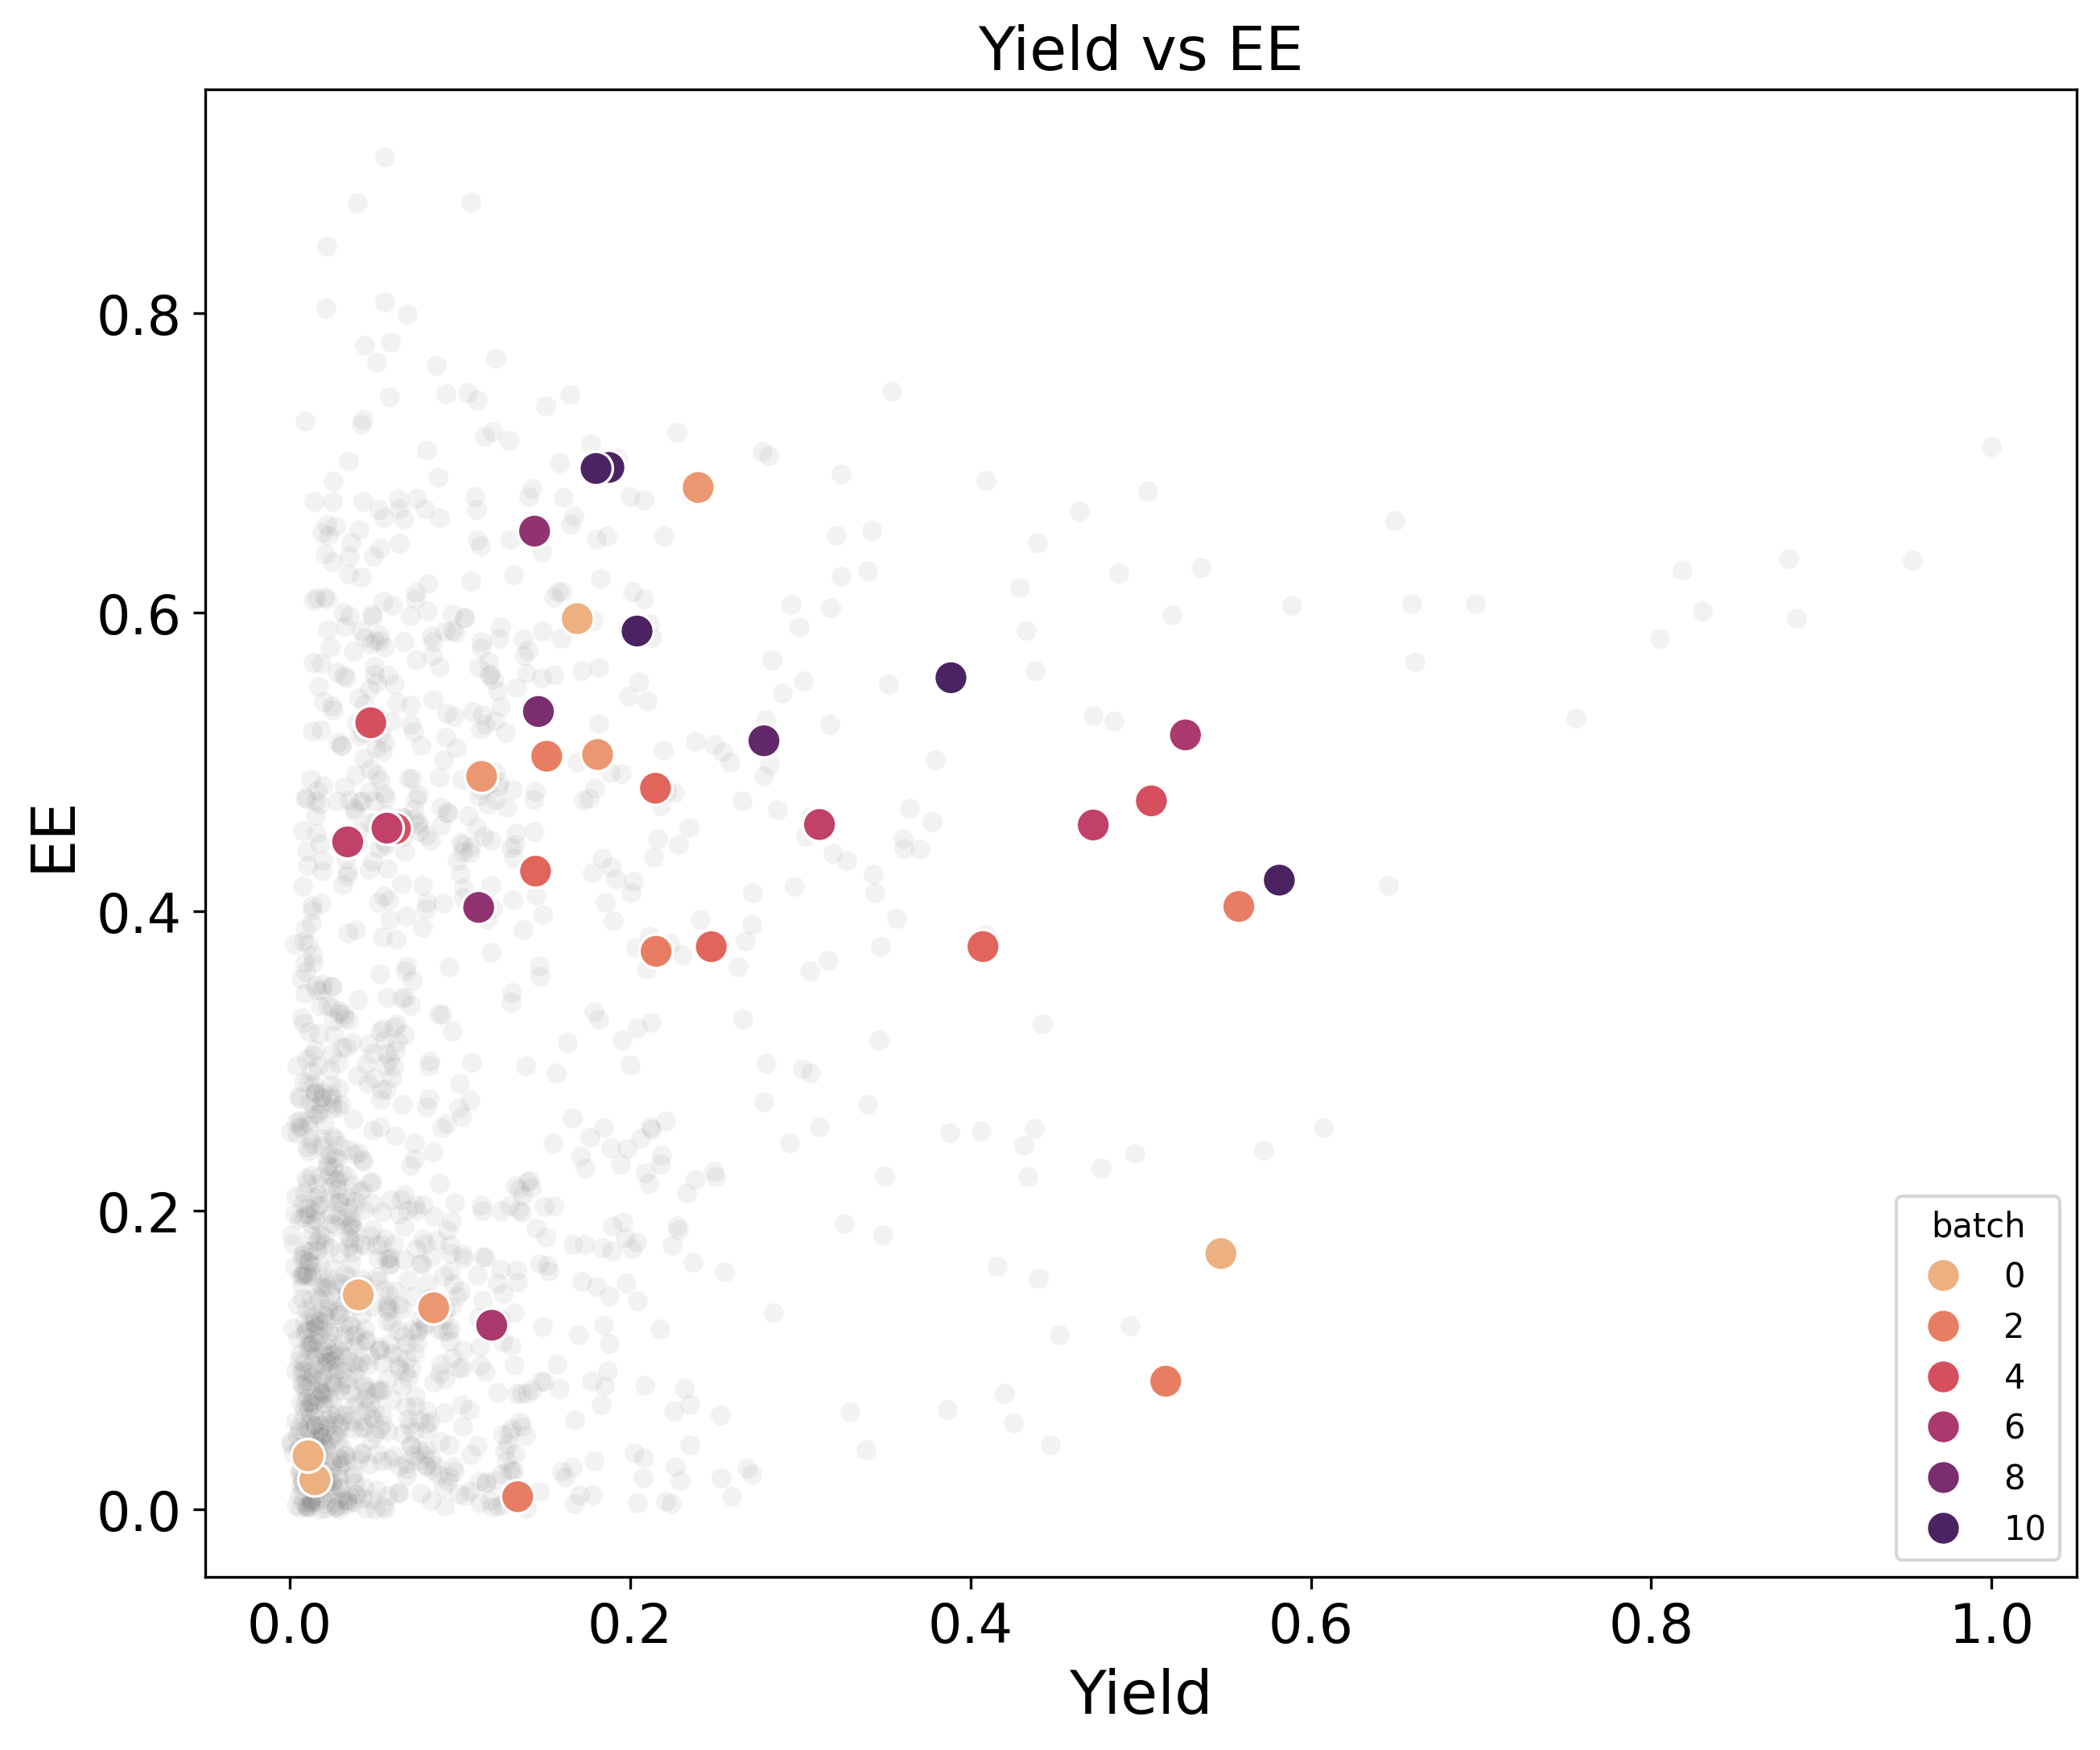

In [103]:
import seaborn as sns
from matplotlib import pyplot as plt

# 绘制 yield 和 ee 的散点图
plt.figure(figsize=(10,8), dpi=300)
sns.scatterplot(data=origin_df, x='yield', y='ee', alpha=0.1, color='gray')
sns.scatterplot(data=total_df, x='yield', y='ee', hue='batch', s=100, palette='flare')
plt.xlabel('Yield', size=18)
plt.ylabel('EE', size=18)
plt.title('Yield vs EE', size=18)
plt.tick_params(axis='both', which='major', labelsize=16)  # 'both'表示同时调整x和y轴
plt.show()


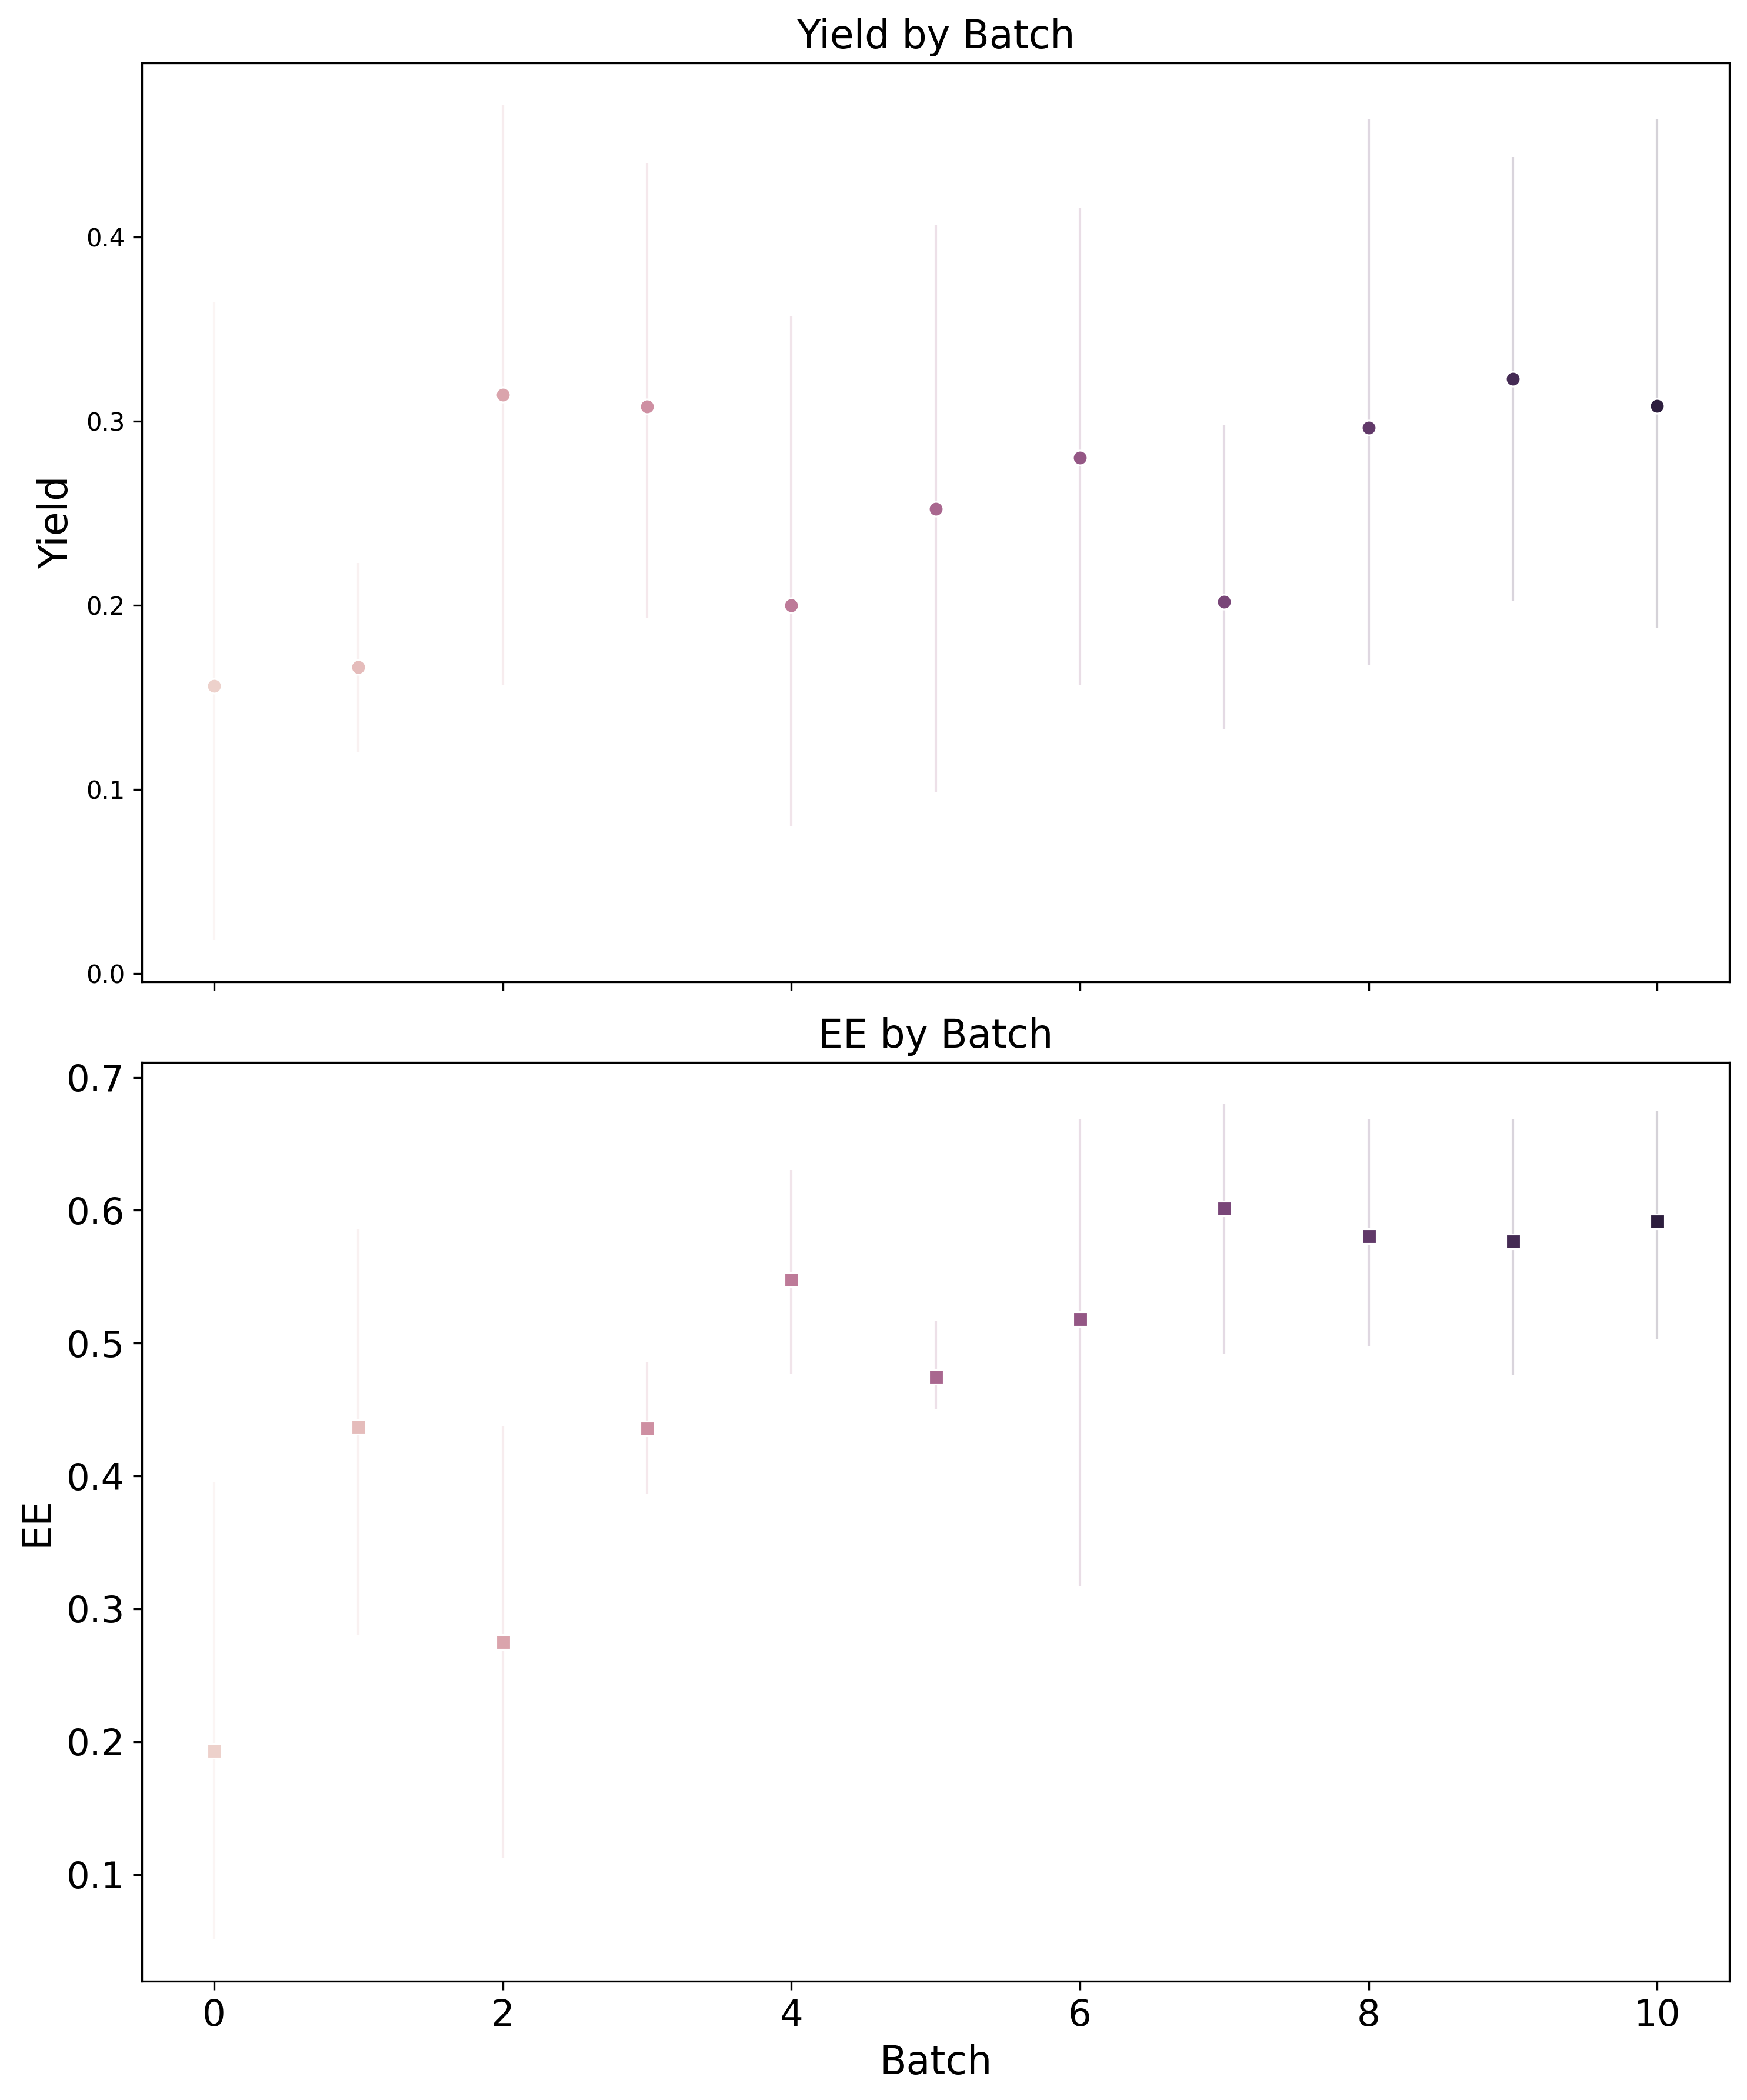

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建画布和子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True, dpi=300)

# 绘制yield子图
sns.lineplot(
    data=total_df, 
    x='batch', 
    y='yield', 
    hue='batch',  # 按batch着色
    ax=ax1,
    marker='o',
    legend=False  # 暂时隐藏图例
)
ax1.set_title('Yield by Batch',size=16)
ax1.set_ylabel('Yield', size=16)

# 绘制ee子图
sns.lineplot(
    data=total_df, 
    x='batch', 
    y='ee', 
    hue='batch',  # 按batch着色
    ax=ax2,
    marker='s',
    legend=False  # 暂时隐藏图例
)
ax2.set_title('EE by Batch', size=16)
ax2.set_ylabel('EE', size=16)
ax2.set_xlabel('Batch', size=16)  # 只在底部子图显示x轴标签
# 调整坐标轴数值标签字体大小
plt.tick_params(axis='both', which='major', labelsize=15)  # 'both'表示同时调整x和y轴

plt.tight_layout()
plt.show()
